In [1]:
# ============================================
# TUGAS 1 - Menjalankan 2 Model
# ============================================

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Load dataset
iris = load_iris()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=1
)

# Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

# Decision Tree (lebih kompleks agar hasil berbeda)
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train, y_train)

print("Kedua model berhasil dilatih.")

Kedua model berhasil dilatih.


In [2]:
# ============================================
# TUGAS 2 - Perbandingan Metrik
# ============================================

from sklearn.metrics import accuracy_score, classification_report

# Prediksi Logistic Regression
pred_lr = lr.predict(X_test)

print("\n=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, pred_lr), 3))
print(classification_report(y_test, pred_lr, target_names=iris.target_names))

# Prediksi Decision Tree
pred_dt = dt.predict(X_test)

print("\n=== Decision Tree ===")
print("Accuracy:", round(accuracy_score(y_test, pred_dt), 3))
print(classification_report(y_test, pred_dt, target_names=iris.target_names))


=== Logistic Regression ===
Accuracy: 0.978
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       1.00      0.94      0.97        18
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


=== Decision Tree ===
Accuracy: 0.956
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.94      0.94      0.94        18
   virginica       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45




=== Confusion Matrix Logistic Regression ===
[[14  0  0]
 [ 0 17  1]
 [ 0  0 13]]

=== Confusion Matrix Decision Tree ===
[[14  0  0]
 [ 0 17  1]
 [ 0  1 12]]


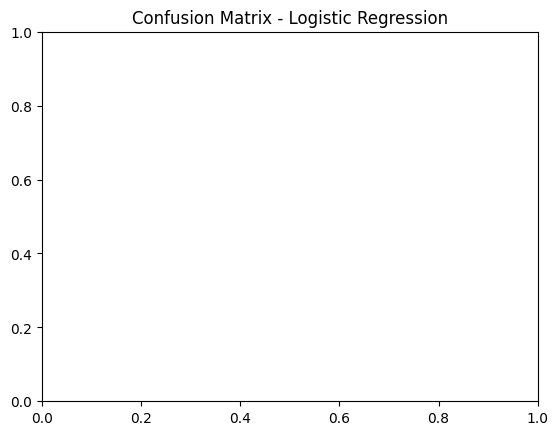

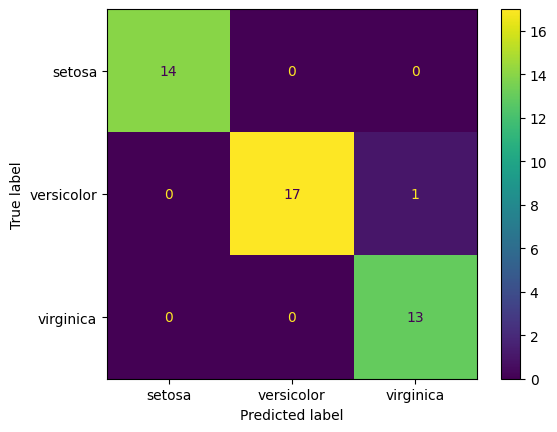

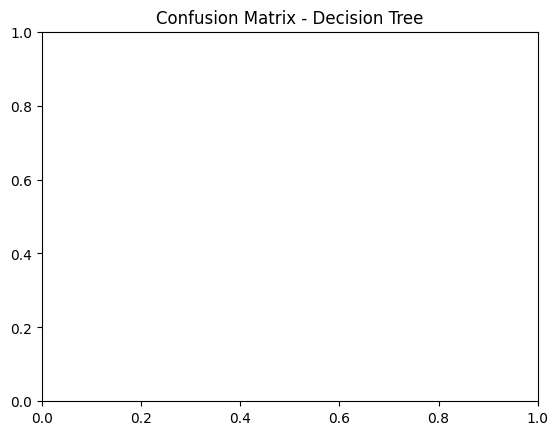

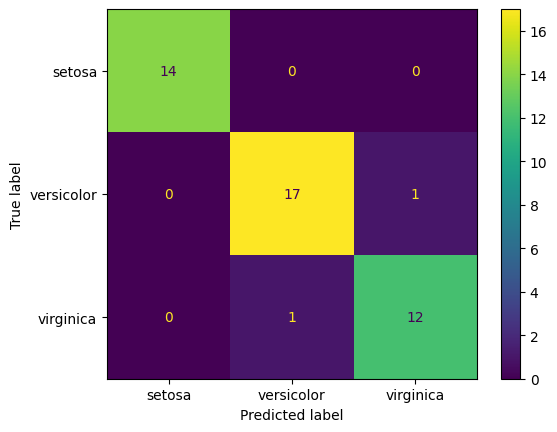

In [3]:
# ============================================
# CONFUSION MATRIX (GRAPH)
# ============================================

# ============================================
# TUGAS 3 - Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix

print("\n=== Confusion Matrix Logistic Regression ===")
print(confusion_matrix(y_test, pred_lr))

print("\n=== Confusion Matrix Decision Tree ===")
print(confusion_matrix(y_test, pred_dt))

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix Logistic Regression
cm_lr = confusion_matrix(y_test, pred_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=iris.target_names
)

plt.title("Confusion Matrix - Logistic Regression")
disp_lr.plot()
plt.show()


# Confusion Matrix Decision Tree
cm_dt = confusion_matrix(y_test, pred_dt)

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=iris.target_names
)

plt.title("Confusion Matrix - Decision Tree")
disp_dt.plot()
plt.show()

In [4]:
# ============================================
# TABEL PERBANDINGAN MODEL
# ============================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hitung metrik Logistic Regression
acc_lr = accuracy_score(y_test, pred_lr)
prec_lr = precision_score(y_test, pred_lr, average='macro')
rec_lr = recall_score(y_test, pred_lr, average='macro')
f1_lr = f1_score(y_test, pred_lr, average='macro')

# Hitung metrik Decision Tree
acc_dt = accuracy_score(y_test, pred_dt)
prec_dt = precision_score(y_test, pred_dt, average='macro')
rec_dt = recall_score(y_test, pred_dt, average='macro')
f1_dt = f1_score(y_test, pred_dt, average='macro')

# Buat tabel perbandingan
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [round(acc_lr,3), round(acc_dt,3)],
    "Precision": [round(prec_lr,3), round(prec_dt,3)],
    "Recall": [round(rec_lr,3), round(rec_dt,3)],
    "F1 Score": [round(f1_lr,3), round(f1_dt,3)]
})

print("\n=== Tabel Perbandingan Model ===")
print(comparison)

# ============================================
# Menentukan Model Terbaik
# ============================================

if acc_lr > acc_dt:
    print("\nModel Terbaik: Logistic Regression")
    print("Alasan: Logistic Regression memiliki nilai Accuracy lebih tinggi")
    print("serta precision, recall, dan F1-score yang lebih baik sehingga")
    print("model ini lebih akurat dalam memprediksi kelas pada dataset Iris.")

elif acc_dt > acc_lr:
    print("\nModel Terbaik: Decision Tree")
    print("Alasan: Decision Tree memiliki nilai Accuracy lebih tinggi")
    print("dan mampu mengklasifikasikan data dengan lebih baik dibanding")
    print("Logistic Regression pada dataset ini.")

else:
    print("\nKedua model memiliki performa yang sama.")
    print("Accuracy keduanya sama sehingga tidak ada model yang lebih unggul.")


=== Tabel Perbandingan Model ===
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.978      0.976   0.981     0.978
1        Decision Tree     0.956      0.956   0.956     0.956

Model Terbaik: Logistic Regression
Alasan: Logistic Regression memiliki nilai Accuracy lebih tinggi
serta precision, recall, dan F1-score yang lebih baik sehingga
model ini lebih akurat dalam memprediksi kelas pada dataset Iris.
